In [1]:
import os
from pathlib import Path
from collections import Counter

# Check dataset structure
dataset_path = Path("/kaggle/input")
print("=== KAGGLE INPUT CONTENTS ===")
for item in sorted(dataset_path.iterdir()):
    print(f"  {item.name}/")

print("\n=== FULL FOLDER TREE ===")
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:  # Show file counts at leaf level
        subindent = "  " * (level + 1)
        ext_counts = Counter(Path(f).suffix.lower() for f in files)
        for ext, count in ext_counts.items():
            print(f"{subindent}{count} files ({ext})")

print("\n=== CLASS-LEVEL COUNTS ===")
for split in ["train", "val", "test"]:
    split_path = None
    for root, dirs, files in os.walk("/kaggle/input"):
        if os.path.basename(root).lower() == split:
            split_path = root
            break
    if split_path:
        print(f"\n{split.upper()}:")
        for cls in sorted(os.listdir(split_path)):
            cls_dir = os.path.join(split_path, cls)
            if os.path.isdir(cls_dir):
                count = len([f for f in os.listdir(cls_dir) 
                             if f.lower().endswith(('.jpg','.jpeg','.png'))])
                print(f"  {cls}: {count} images")

=== KAGGLE INPUT CONTENTS ===
  datasets/

=== FULL FOLDER TREE ===
input/
  datasets/
    paultimothymooney/
      chest-xray-pneumonia/
        chest_xray/
          chest_xray/
            1 files ()
            val/
              1 files ()
              PNEUMONIA/
                8 files (.jpeg)
                1 files ()
              NORMAL/
                8 files (.jpeg)
                1 files ()
            test/
              1 files ()
              PNEUMONIA/
                390 files (.jpeg)
              NORMAL/
                234 files (.jpeg)
            train/
              1 files ()
              PNEUMONIA/
                3875 files (.jpeg)
                1 files ()
              NORMAL/
                1341 files (.jpeg)
                1 files ()
          __MACOSX/
            1 files ()
            chest_xray/
              1 files (.ds_store)
              2 files ()
              val/
                1 files (.ds_store)
                PNEUMONIA/
         

In [2]:
import os, torch, numpy as np, matplotlib.pyplot as plt, shutil, copy
from pathlib import Path
from torch import nn, optim
from torch.utils.data import DataLoader, WeightedRandomSampler, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import seaborn as sns

print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU'}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.10.0+cu128
GPU: Tesla T4


In [3]:
# Correct path (double nested)
RAW      = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray")
WORK_DIR = Path("/kaggle/working/dataset")

classes = ["NORMAL", "BACTERIAL", "VIRAL"]

for split in ["train", "val", "test"]:
    for cls in classes:
        (WORK_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def copy_pneumonia(src_dir, dst_split):
    """Copy NORMAL as-is, split PNEUMONIA by filename prefix."""
    normal_dir    = src_dir / "NORMAL"
    pneumonia_dir = src_dir / "PNEUMONIA"
    counts = Counter()

    for f in normal_dir.glob("*.jpeg"):
        shutil.copy(f, WORK_DIR / dst_split / "NORMAL" / f.name)
        counts["NORMAL"] += 1

    for f in pneumonia_dir.glob("*.jpeg"):
        upper = f.name.upper()
        if upper.startswith("BACTERIA"):
            shutil.copy(f, WORK_DIR / dst_split / "BACTERIAL" / f.name)
            counts["BACTERIAL"] += 1
        elif upper.startswith("VIRUS"):
            shutil.copy(f, WORK_DIR / dst_split / "VIRAL" / f.name)
            counts["VIRAL"] += 1

    return counts

# Merge original train + val → our train (val was only 8 images, useless)
c1 = copy_pneumonia(RAW / "train", "train")
c2 = copy_pneumonia(RAW / "val",   "train")  # merge into train
c3 = copy_pneumonia(RAW / "test",  "test")

print(f"Train (merged): NORMAL={c1['NORMAL']+c2['NORMAL']} "
      f"BACTERIAL={c1['BACTERIAL']+c2['BACTERIAL']} "
      f"VIRAL={c1['VIRAL']+c2['VIRAL']}")
print(f"Test:           NORMAL={c3['NORMAL']} BACTERIAL={c3['BACTERIAL']} VIRAL={c3['VIRAL']}")

# Carve 15% of train → our val (stratified by moving files)
import random
random.seed(42)
for cls in classes:
    files = list((WORK_DIR / "train" / cls).glob("*.jpeg"))
    random.shuffle(files)
    val_count = int(len(files) * 0.15)
    for f in files[:val_count]:
        shutil.move(str(f), str(WORK_DIR / "val" / cls / f.name))
    print(f"  {cls}: {len(files)-val_count} train | {val_count} val")

print("\nFinal counts:")
for split in ["train", "val", "test"]:
    row = []
    for cls in classes:
        n = len(list((WORK_DIR / split / cls).glob("*.jpeg")))
        row.append(f"{cls}={n}")
    print(f"  {split}: {', '.join(row)}")

Train (merged): NORMAL=1349 BACTERIAL=0 VIRAL=0
Test:           NORMAL=234 BACTERIAL=0 VIRAL=0
  NORMAL: 1147 train | 202 val
  BACTERIAL: 0 train | 0 val
  VIRAL: 0 train | 0 val

Final counts:
  train: NORMAL=1147, BACTERIAL=0, VIRAL=0
  val: NORMAL=202, BACTERIAL=0, VIRAL=0
  test: NORMAL=234, BACTERIAL=0, VIRAL=0


In [4]:
IMG_SIZE = 224
BATCH    = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(WORK_DIR / "train", transform=train_tf)
val_ds   = ImageFolder(WORK_DIR / "val",   transform=val_tf)
test_ds  = ImageFolder(WORK_DIR / "test",  transform=val_tf)

# Weighted sampler — fixes class imbalance in train
counts  = Counter(train_ds.targets)
weights = [1.0 / counts[t] for t in train_ds.targets]
sampler = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)

print(f"Classes : {train_ds.classes}")
print(f"Train   : {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Class distribution in train: {dict(counts)}")

FileNotFoundError: Found no valid file for the classes BACTERIAL, VIRAL. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [2]:
RAW = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray")

pneumonia_dir = RAW / "train" / "PNEUMONIA"
files = list(pneumonia_dir.glob("*.jpeg"))[:20]  # first 20 only

print(f"Total PNEUMONIA files: {len(list(pneumonia_dir.glob('*.jpeg')))}")
print("\nFirst 20 filenames:")
for f in sorted(files):
    print(f"  {f.name}")

Total PNEUMONIA files: 3875

First 20 filenames:
  person1180_virus_2010.jpeg
  person1230_virus_2081.jpeg
  person124_virus_238.jpeg
  person1361_bacteria_3476.jpeg
  person1418_bacteria_3636.jpeg
  person1513_virus_2632.jpeg
  person1527_virus_2661.jpeg
  person1590_bacteria_4175.jpeg
  person1689_bacteria_4472.jpeg
  person399_bacteria_1805.jpeg
  person437_bacteria_1884.jpeg
  person466_virus_960.jpeg
  person494_virus_1000.jpeg
  person57_bacteria_270.jpeg
  person588_bacteria_2422.jpeg
  person59_bacteria_279.jpeg
  person600_bacteria_2456.jpeg
  person622_bacteria_2494.jpeg
  person746_virus_1369.jpeg
  person97_virus_180.jpeg


In [3]:
import shutil, random
from pathlib import Path
from collections import Counter

RAW      = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray")
WORK_DIR = Path("/kaggle/working/dataset")

classes = ["NORMAL", "BACTERIAL", "VIRAL"]

# Clean and recreate
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
for split in ["train", "val", "test"]:
    for cls in classes:
        (WORK_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def copy_split(src_dir, dst_split):
    counts = Counter()
    for f in (src_dir / "NORMAL").glob("*.jpeg"):
        shutil.copy(f, WORK_DIR / dst_split / "NORMAL" / f.name)
        counts["NORMAL"] += 1
    for f in (src_dir / "PNEUMONIA").glob("*.jpeg"):
        name = f.name.lower()
        if "_bacteria_" in name:
            shutil.copy(f, WORK_DIR / dst_split / "BACTERIAL" / f.name)
            counts["BACTERIAL"] += 1
        elif "_virus_" in name:
            shutil.copy(f, WORK_DIR / dst_split / "VIRAL" / f.name)
            counts["VIRAL"] += 1
    return counts

# Merge original train + val → our train (original val only had 8 images)
c1 = copy_split(RAW / "train", "train")
c2 = copy_split(RAW / "val",   "train")
c3 = copy_split(RAW / "test",  "test")

print(f"After merge → Train: {dict(c1 + c2)}")
print(f"Test:                {dict(c3)}")

# Carve 15% stratified val from train
random.seed(42)
print("\nTrain/Val split:")
for cls in classes:
    files = list((WORK_DIR / "train" / cls).glob("*.jpeg"))
    random.shuffle(files)
    val_n = int(len(files) * 0.15)
    for f in files[:val_n]:
        shutil.move(str(f), str(WORK_DIR / "val" / cls / f.name))
    print(f"  {cls}: {len(files)-val_n} train | {val_n} val")

print("\nFinal counts:")
for split in ["train", "val", "test"]:
    row = {cls: len(list((WORK_DIR/split/cls).glob("*.jpeg"))) for cls in classes}
    print(f"  {split}: {row}")

KeyboardInterrupt: 

In [7]:
IMG_SIZE = 224
BATCH    = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(WORK_DIR / "train", transform=train_tf)
val_ds   = ImageFolder(WORK_DIR / "val",   transform=val_tf)
test_ds  = ImageFolder(WORK_DIR / "test",  transform=val_tf)

# Weighted sampler — fixes class imbalance in train
counts  = Counter(train_ds.targets)
weights = [1.0 / counts[t] for t in train_ds.targets]
sampler = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)

print(f"Classes : {train_ds.classes}")
print(f"Train   : {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Class distribution in train: {dict(counts)}")

Classes : ['BACTERIAL', 'NORMAL', 'VIRAL']
Train   : 4449 | Val: 783 | Test: 624
Class distribution in train: {0: 2158, 1: 1147, 2: 1144}


In [8]:
model = models.densenet121(weights="IMAGENET1K_V1")

# Freeze everything except last dense block + classifier
for name, param in model.named_parameters():
    param.requires_grad = "denseblock4" in name or "classifier" in name

# New 3-class head
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 3)
)

model = model.to(device)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 163MB/s]


Trainable params: 2,421,251


In [10]:
EPOCHS = 25
LR     = 1e-4

# Loss weighted by inverse class frequency
total  = sum(counts.values())
cw     = torch.tensor([total / (3 * counts[i]) for i in range(3)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=cw)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=4
)

best_wts    = copy.deepcopy(model.state_dict())
best_val    = 0.0
history     = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
no_improve  = 0
PATIENCE    = 8   # early stopping

for epoch in range(EPOCHS):
    for phase in ["train", "val"]:
        model.train() if phase == "train" else model.eval()
        loader = train_loader if phase == "train" else val_loader
        loss_sum, correct, total_n = 0.0, 0, 0

        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == "train"):
                out  = model(imgs)
                loss = criterion(out, labels)
                if phase == "train":
                    loss.backward()
                    optimizer.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total_n  += labels.size(0)

        ep_loss = loss_sum / total_n
        ep_acc  = correct  / total_n
        history[f"{phase}_loss"].append(ep_loss)
        history[f"{phase}_acc"].append(ep_acc)

        if phase == "val":
            scheduler.step(ep_acc)
            if ep_acc > best_val:
                best_val = ep_acc
                best_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), "/kaggle/working/pneumonia_densenet121.pth")
                no_improve = 0
            else:
                no_improve += 1

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss {history['train_loss'][-1]:.4f} Acc {history['train_acc'][-1]:.4f} | "
          f"Val Loss {history['val_loss'][-1]:.4f} Acc {history['val_acc'][-1]:.4f}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_wts)
print(f"\nBest Val Acc: {best_val:.4f}")

Epoch 01 | Train Loss 0.6500 Acc 0.6498 | Val Loss 0.6042 Acc 0.7548
Epoch 02 | Train Loss 0.4539 Acc 0.7651 | Val Loss 0.5813 Acc 0.7561
Epoch 03 | Train Loss 0.4358 Acc 0.7649 | Val Loss 0.4901 Acc 0.8008
Epoch 04 | Train Loss 0.3999 Acc 0.7939 | Val Loss 0.5204 Acc 0.7676
Epoch 05 | Train Loss 0.3894 Acc 0.8022 | Val Loss 0.6028 Acc 0.7190
Epoch 06 | Train Loss 0.3680 Acc 0.8159 | Val Loss 0.5183 Acc 0.7829
Epoch 07 | Train Loss 0.3587 Acc 0.8148 | Val Loss 0.4803 Acc 0.7905
Epoch 08 | Train Loss 0.3628 Acc 0.8150 | Val Loss 0.5210 Acc 0.7561
Epoch 09 | Train Loss 0.3375 Acc 0.8263 | Val Loss 0.4817 Acc 0.7893
Epoch 10 | Train Loss 0.3252 Acc 0.8348 | Val Loss 0.4684 Acc 0.8033
Epoch 11 | Train Loss 0.3146 Acc 0.8375 | Val Loss 0.4729 Acc 0.7918
Epoch 12 | Train Loss 0.3071 Acc 0.8469 | Val Loss 0.4649 Acc 0.8020
Epoch 13 | Train Loss 0.2995 Acc 0.8577 | Val Loss 0.5445 Acc 0.7714
Epoch 14 | Train Loss 0.3063 Acc 0.8431 | Val Loss 0.5441 Acc 0.7625
Epoch 15 | Train Loss 0.3064 Acc 0

TEST SET RESULTS
              precision    recall  f1-score   support

   BACTERIAL     0.8943    0.9091    0.9016       242
      NORMAL     0.9651    0.7094    0.8177       234
       VIRAL     0.6165    0.8581    0.7175       148

    accuracy                         0.8221       624
   macro avg     0.8253    0.8255    0.8123       624
weighted avg     0.8550    0.8221    0.8265       624



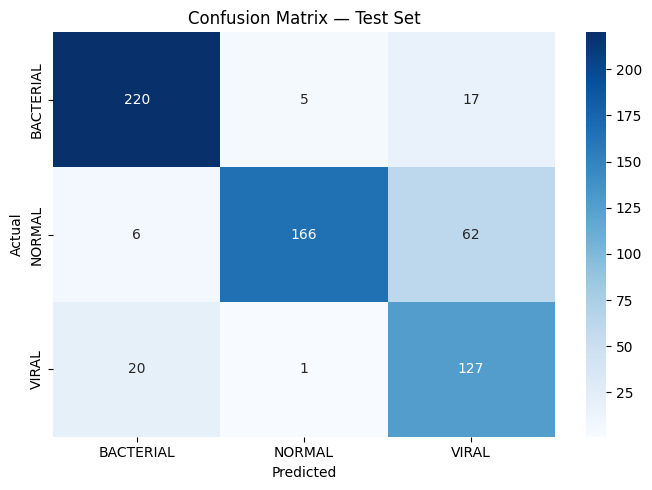

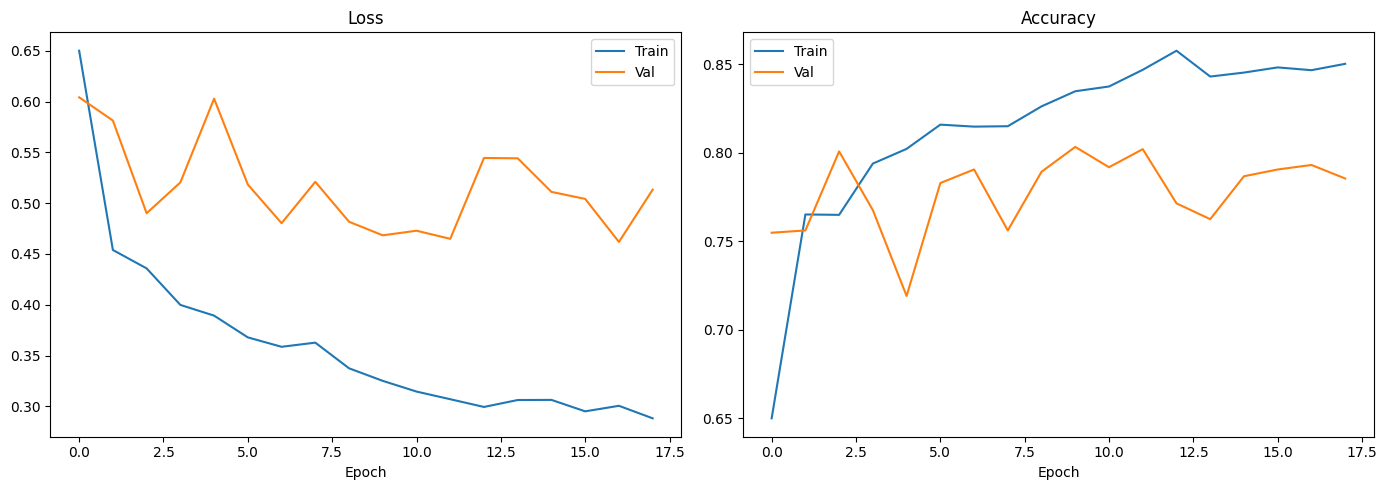


Model saved → /kaggle/working/pneumonia_densenet121.pth


In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(classification_report(all_labels, all_preds,
                             target_names=train_ds.classes, digits=4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("Loss"); ax1.legend(); ax1.set_xlabel("Epoch")
ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.set_title("Accuracy"); ax2.legend(); ax2.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png")
plt.show()

print("\nModel saved → /kaggle/working/pneumonia_densenet121.pth")

In [12]:
# Unfreeze ALL layers now
for param in model.parameters():
    param.requires_grad = True

EPOCHS2 = 20
LR2     = 1e-5  # much lower — critical when unfreezing all layers

optimizer2 = optim.Adam(model.parameters(), lr=LR2, weight_decay=1e-4)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=EPOCHS2, eta_min=1e-7)

best_wts2   = copy.deepcopy(model.state_dict())
best_val2   = best_val  # continue from previous best
history2    = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
no_improve2 = 0
PATIENCE2   = 6

for epoch in range(EPOCHS2):
    for phase in ["train", "val"]:
        model.train() if phase == "train" else model.eval()
        loader = train_loader if phase == "train" else val_loader
        loss_sum, correct, total_n = 0.0, 0, 0

        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer2.zero_grad()
            with torch.set_grad_enabled(phase == "train"):
                out  = model(imgs)
                loss = criterion(out, labels)
                if phase == "train":
                    loss.backward()
                    optimizer2.step()
            loss_sum += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total_n  += labels.size(0)

        ep_loss = loss_sum / total_n
        ep_acc  = correct  / total_n
        history2[f"{phase}_loss"].append(ep_loss)
        history2[f"{phase}_acc"].append(ep_acc)

        if phase == "val":
            scheduler2.step()
            if ep_acc > best_val2:
                best_val2 = ep_acc
                best_wts2 = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), "/kaggle/working/pneumonia_densenet121_v2.pth")
                no_improve2 = 0
            else:
                no_improve2 += 1

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss {history2['train_loss'][-1]:.4f} Acc {history2['train_acc'][-1]:.4f} | "
          f"Val Loss {history2['val_loss'][-1]:.4f} Acc {history2['val_acc'][-1]:.4f}"
          f"{'  ← best' if history2['val_acc'][-1] == best_val2 else ''}")

    if no_improve2 >= PATIENCE2:
        print(f"Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_wts2)
print(f"\nBest Val Acc Phase 2: {best_val2:.4f}")

Epoch 01 | Train Loss 0.3304 Acc 0.8341 | Val Loss 0.4708 Acc 0.7880
Epoch 02 | Train Loss 0.3278 Acc 0.8301 | Val Loss 0.4841 Acc 0.7905
Epoch 03 | Train Loss 0.3000 Acc 0.8467 | Val Loss 0.4449 Acc 0.8110  ← best
Epoch 04 | Train Loss 0.2885 Acc 0.8546 | Val Loss 0.5054 Acc 0.7893
Epoch 05 | Train Loss 0.2755 Acc 0.8602 | Val Loss 0.4979 Acc 0.7969
Epoch 06 | Train Loss 0.2887 Acc 0.8526 | Val Loss 0.4430 Acc 0.8033
Epoch 07 | Train Loss 0.2568 Acc 0.8748 | Val Loss 0.5444 Acc 0.7854
Epoch 08 | Train Loss 0.2568 Acc 0.8685 | Val Loss 0.4951 Acc 0.7982
Epoch 09 | Train Loss 0.2497 Acc 0.8768 | Val Loss 0.5402 Acc 0.7918
Early stopping at epoch 9

Best Val Acc Phase 2: 0.8110


GPU: Tesla T4
Final counts:
  train: {'NORMAL': 1147, 'BACTERIAL': 2158, 'VIRAL': 1144}
  val: {'NORMAL': 202, 'BACTERIAL': 380, 'VIRAL': 201}
  test: {'NORMAL': 234, 'BACTERIAL': 242, 'VIRAL': 148}

Classes : ['BACTERIAL', 'NORMAL', 'VIRAL']
Train 4449 | Val 783 | Test 624
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 194MB/s]



Phase 1 trainable params: 4,665,597

PHASE 1 — Warm-up (frozen backbone)
[P1] Ep 01 | Train 0.6887 Loss 0.7056 | Val 0.7522 Loss 0.7762  ← best
[P1] Ep 02 | Train 0.7442 Loss 0.6446 | Val 0.6564 Loss 1.0023
[P1] Ep 03 | Train 0.7577 Loss 0.6188 | Val 0.6833 Loss 0.9527
[P1] Ep 04 | Train 0.7710 Loss 0.6112 | Val 0.6845 Loss 0.8805
[P1] Ep 05 | Train 0.7703 Loss 0.5968 | Val 0.6616 Loss 0.9017
[P1] Ep 06 | Train 0.7921 Loss 0.5674 | Val 0.7152 Loss 0.8404
Early stopping at epoch 6

Phase 1 best val acc: 0.7522

PHASE 2 — Full fine-tune (all layers)
[P2] Ep 01 | Train 0.7647 Loss 0.6374 | Val 0.6679 Loss 0.9061  ← best
[P2] Ep 02 | Train 0.7732 Loss 0.6008 | Val 0.7395 Loss 0.8042  ← best
[P2] Ep 03 | Train 0.7743 Loss 0.6053 | Val 0.7254 Loss 0.8090
[P2] Ep 04 | Train 0.7885 Loss 0.5917 | Val 0.6960 Loss 0.8927
[P2] Ep 05 | Train 0.7894 Loss 0.5829 | Val 0.7190 Loss 0.8167
[P2] Ep 06 | Train 0.7833 Loss 0.5919 | Val 0.7190 Loss 0.8320
[P2] Ep 07 | Train 0.7851 Loss 0.5849 | Val 0.7267 

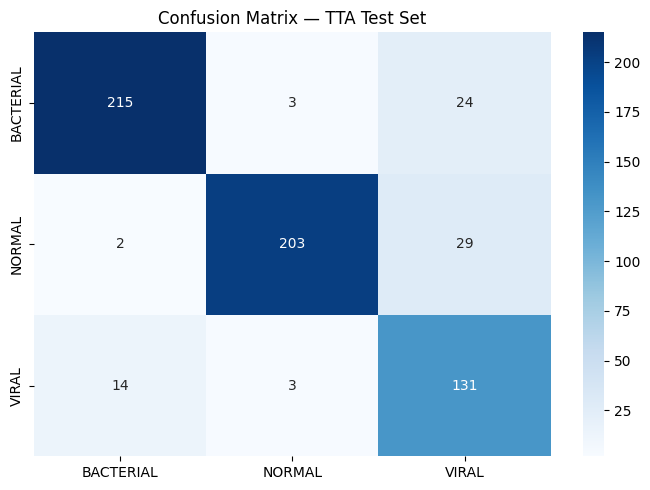

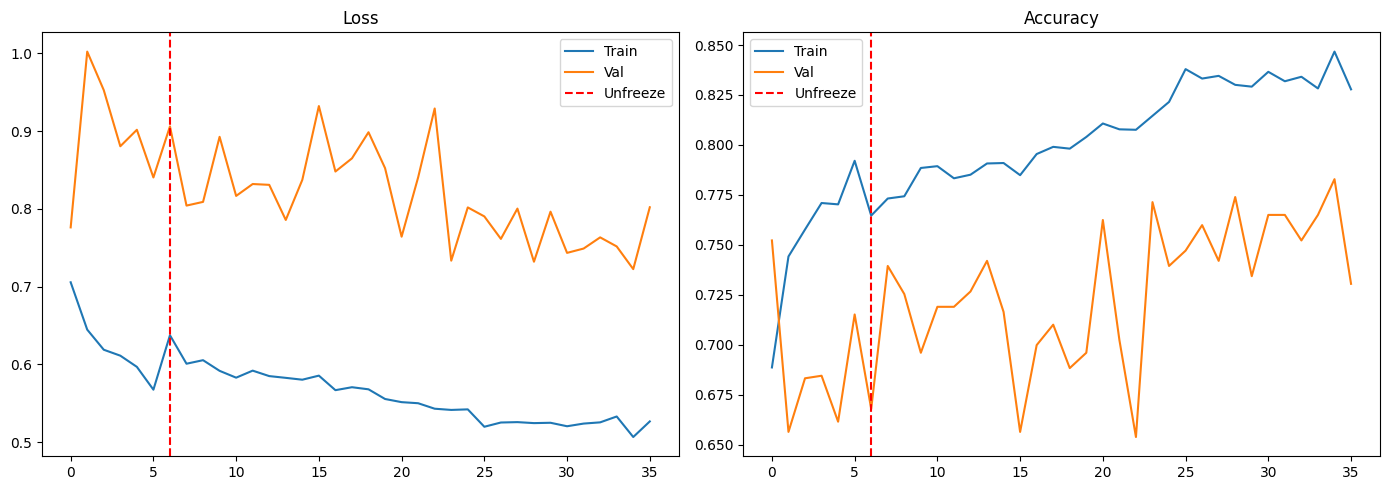


FINAL SUMMARY
  Model         : EfficientNet-B3 (ImageNet → fine-tuned)
  Test Accuracy : 87.98%
  Best Val Acc  : 78.29%
  Macro F1      : 0.8716

  Per-class F1:
    BACTERIAL    ███████████████████████████    0.9091
    NORMAL       ███████████████████████████    0.9165
    VIRAL        ███████████████████████        0.7892


In [13]:
import os, torch, numpy as np, matplotlib.pyplot as plt
import shutil, copy, random, json
from pathlib import Path
from torch import nn, optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
import seaborn as sns
from PIL import Image

# ── Seed everything ───────────────────────────────────────────────
def seed_all(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
seed_all()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# ══════════════════════════════════════════════════════════════════
# 1. DATASET SETUP
# ══════════════════════════════════════════════════════════════════
RAW      = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray")
WORK_DIR = Path("/kaggle/working/dataset")

classes = ["NORMAL", "BACTERIAL", "VIRAL"]

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
for split in ["train", "val", "test"]:
    for cls in classes:
        (WORK_DIR / split / cls).mkdir(parents=True, exist_ok=True)

def copy_split(src_dir, dst_split):
    counts = Counter()
    normal_dir    = src_dir / "NORMAL"
    pneumonia_dir = src_dir / "PNEUMONIA"
    if normal_dir.exists():
        for f in normal_dir.glob("*.jpeg"):
            shutil.copy(f, WORK_DIR / dst_split / "NORMAL" / f.name)
            counts["NORMAL"] += 1
    if pneumonia_dir.exists():
        for f in pneumonia_dir.glob("*.jpeg"):
            name = f.name.lower()
            if "_bacteria_" in name:
                shutil.copy(f, WORK_DIR / dst_split / "BACTERIAL" / f.name)
                counts["BACTERIAL"] += 1
            elif "_virus_" in name:
                shutil.copy(f, WORK_DIR / dst_split / "VIRAL" / f.name)
                counts["VIRAL"] += 1
    return counts

c1 = copy_split(RAW / "train", "train")
c2 = copy_split(RAW / "val",   "train")   # merge tiny val into train
c3 = copy_split(RAW / "test",  "test")

# Stratified 15% val split
random.seed(42)
for cls in classes:
    files = list((WORK_DIR / "train" / cls).glob("*.jpeg"))
    random.shuffle(files)
    val_n = int(len(files) * 0.15)
    for f in files[:val_n]:
        shutil.move(str(f), str(WORK_DIR / "val" / cls / f.name))

print("Final counts:")
for split in ["train", "val", "test"]:
    row = {cls: len(list((WORK_DIR/split/cls).glob("*.jpeg"))) for cls in classes}
    print(f"  {split}: {row}")

# ══════════════════════════════════════════════════════════════════
# 2. TRANSFORMS  (heavy augmentation on train)
# ══════════════════════════════════════════════════════════════════
IMG_SIZE = 224
BATCH    = 32

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=5),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# TTA transforms (used at inference)
tta_tfs = [
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((256,256)), transforms.CenterCrop(IMG_SIZE),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomRotation((10,10)),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]

train_ds = ImageFolder(WORK_DIR / "train", transform=train_tf)
val_ds   = ImageFolder(WORK_DIR / "val",   transform=val_tf)
test_ds  = ImageFolder(WORK_DIR / "test",  transform=val_tf)

counts  = Counter(train_ds.targets)
weights = [1.0 / counts[t] for t in train_ds.targets]
sampler = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)

print(f"\nClasses : {train_ds.classes}")
print(f"Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}")

# ══════════════════════════════════════════════════════════════════
# 3. MODEL — EfficientNet-B3 (better than DenseNet for medical)
# ══════════════════════════════════════════════════════════════════
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

# Phase 1: freeze all except last 2 blocks + classifier
for name, param in model.named_parameters():
    param.requires_grad = any(x in name for x in ["features.7", "features.8", "classifier"])

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, 3)
)
model = model.to(device)
print(f"\nPhase 1 trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ══════════════════════════════════════════════════════════════════
# 4. LOSS — label smoothing reduces overconfidence
# ══════════════════════════════════════════════════════════════════
total_n = sum(counts.values())
cw = torch.tensor([total_n/(3*counts[i]) for i in range(3)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)

# ══════════════════════════════════════════════════════════════════
# 5. TRAINING FUNCTION
# ══════════════════════════════════════════════════════════════════
def run_epoch(model, loader, optimizer=None, phase="train"):
    model.train() if phase == "train" else model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if optimizer: optimizer.zero_grad()
        with torch.set_grad_enabled(phase == "train"):
            out  = model(imgs)
            loss = criterion(out, labels)
            if phase == "train":
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += labels.size(0)
    return loss_sum/total, correct/total

def train_phase(model, train_loader, val_loader, optimizer, scheduler,
                epochs, patience, label, save_path):
    best_wts = copy.deepcopy(model.state_dict())
    best_val = 0.0
    history  = {"tl":[], "vl":[], "ta":[], "va":[]}
    no_imp   = 0
    for ep in range(epochs):
        tl, ta = run_epoch(model, train_loader, optimizer, "train")
        vl, va = run_epoch(model, val_loader,   None,      "val")
        history["tl"].append(tl); history["ta"].append(ta)
        history["vl"].append(vl); history["va"].append(va)
        if hasattr(scheduler, 'step'):
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va)
            else:
                scheduler.step()
        improved = ""
        if va > best_val:
            best_val = va; best_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            no_imp = 0; improved = "  ← best"
        else:
            no_imp += 1
        print(f"[{label}] Ep {ep+1:02d} | "
              f"Train {ta:.4f} Loss {tl:.4f} | "
              f"Val {va:.4f} Loss {vl:.4f}{improved}")
        if no_imp >= patience:
            print(f"Early stopping at epoch {ep+1}")
            break
    model.load_state_dict(best_wts)
    return model, best_val, history

# ══════════════════════════════════════════════════════════════════
# 6. PHASE 1 — warm up classifier + top blocks
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("PHASE 1 — Warm-up (frozen backbone)")
print("="*55)

opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                  lr=1e-3, weight_decay=1e-4)
sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=10, eta_min=1e-5)

model, best1, hist1 = train_phase(
    model, train_loader, val_loader,
    opt1, sch1, epochs=10, patience=5,
    label="P1", save_path="/kaggle/working/phase1_best.pth"
)
print(f"\nPhase 1 best val acc: {best1:.4f}")

# ══════════════════════════════════════════════════════════════════
# 7. PHASE 2 — unfreeze all, fine-tune with tiny LR
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("PHASE 2 — Full fine-tune (all layers)")
print("="*55)

for param in model.parameters():
    param.requires_grad = True

opt2 = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt2, T_0=10, T_mult=2, eta_min=1e-7)

model, best2, hist2 = train_phase(
    model, train_loader, val_loader,
    opt2, sch2, epochs=30, patience=8,
    label="P2", save_path="/kaggle/working/phase2_best.pth"
)
print(f"\nPhase 2 best val acc: {best2:.4f}")

# ══════════════════════════════════════════════════════════════════
# 8. TTA INFERENCE on test set
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("EVALUATING WITH TTA (Test Time Augmentation)")
print("="*55)

class TTADataset(Dataset):
    def __init__(self, dataset, tf): self.ds = dataset; self.tf = tf
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        path, label = self.ds.samples[i]
        img = Image.open(path).convert("RGB")
        return self.tf(img), label

model.eval()
all_probs  = []
all_labels = []

# First pass — collect labels
for _, labels in test_loader:
    all_labels.extend(labels.numpy())

# TTA passes
for tf_idx, tf in enumerate(tta_tfs):
    tta_ds     = TTADataset(test_ds, tf)
    tta_loader = DataLoader(tta_ds, batch_size=BATCH, shuffle=False, num_workers=2)
    probs_pass = []
    with torch.no_grad():
        for imgs, _ in tta_loader:
            out = torch.softmax(model(imgs.to(device)), dim=1).cpu()
            probs_pass.append(out)
    all_probs.append(torch.cat(probs_pass))
    print(f"  TTA pass {tf_idx+1}/{len(tta_tfs)} done")

# Average probabilities across TTA passes
avg_probs  = torch.stack(all_probs).mean(0)
tta_preds  = avg_probs.argmax(1).numpy()

# Also get standard (no TTA) predictions for comparison
model.eval()
std_preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        std_preds.extend(model(imgs.to(device)).argmax(1).cpu().numpy())

print("\n" + "="*55)
print("STANDARD INFERENCE — Test Results")
print("="*55)
print(classification_report(all_labels, std_preds,
                             target_names=train_ds.classes, digits=4))

print("="*55)
print("TTA INFERENCE — Test Results")
print("="*55)
report_str = classification_report(all_labels, tta_preds,
                                   target_names=train_ds.classes, digits=4)
report_dict = classification_report(all_labels, tta_preds,
                                    target_names=train_ds.classes,
                                    digits=4, output_dict=True)
print(report_str)

# ══════════════════════════════════════════════════════════════════
# 9. PLOTS
# ══════════════════════════════════════════════════════════════════
# Confusion matrix
cm = confusion_matrix(all_labels, tta_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.title("Confusion Matrix — TTA Test Set"); plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_final.png", dpi=150)
plt.show()

# Combined training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
p1_len = len(hist1["ta"])
all_ta = hist1["ta"] + hist2["ta"]; all_va = hist1["va"] + hist2["va"]
all_tl = hist1["tl"] + hist2["tl"]; all_vl = hist1["vl"] + hist2["vl"]
ax1.plot(all_tl, label="Train"); ax1.plot(all_vl, label="Val")
ax1.axvline(p1_len, color="red", linestyle="--", label="Unfreeze")
ax1.set_title("Loss"); ax1.legend()
ax2.plot(all_ta, label="Train"); ax2.plot(all_va, label="Val")
ax2.axvline(p1_len, color="red", linestyle="--", label="Unfreeze")
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_final.png", dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════
# 10. SAVE SUMMARY
# ══════════════════════════════════════════════════════════════════
summary = {
    "model"          : "EfficientNet-B3 + TTA",
    "test_accuracy"  : round(accuracy_score(all_labels, tta_preds), 4),
    "best_val_acc"   : round(best2, 4),
    "macro_f1"       : round(report_dict["macro avg"]["f1-score"], 4),
    "per_class"      : {
        cls: {k: round(report_dict[cls][k], 4) for k in ["precision","recall","f1-score","support"]}
        for cls in train_ds.classes
    }
}
with open("/kaggle/working/summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*55)
print("FINAL SUMMARY")
print("="*55)
print(f"  Model         : EfficientNet-B3 (ImageNet → fine-tuned)")
print(f"  Test Accuracy : {summary['test_accuracy']*100:.2f}%")
print(f"  Best Val Acc  : {summary['best_val_acc']*100:.2f}%")
print(f"  Macro F1      : {summary['macro_f1']:.4f}")
print("\n  Per-class F1:")
for cls, m in summary["per_class"].items():
    bar = "█" * int(m["f1-score"] * 30)
    print(f"    {cls:<12} {bar:<30} {m['f1-score']:.4f}")

GPU: Tesla T4
Final counts:
  train: {'NORMAL': 1080, 'BACTERIAL': 2031, 'VIRAL': 1076}
  val: {'NORMAL': 269, 'BACTERIAL': 507, 'VIRAL': 269}
  test: {'NORMAL': 234, 'BACTERIAL': 242, 'VIRAL': 148}
Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']
Train 4187 | Val 1045 | Test 624
Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 131MB/s]  


Phase 1 trainable: 262,659

PHASE 1 — Head warm-up (backbone frozen)
[P1] Ep 01 | Train 0.6611 Loss 0.7482 | Val 0.6459 Loss 0.8540  ← best
[P1] Ep 02 | Train 0.7022 Loss 0.6869 | Val 0.6354 Loss 0.8367
[P1] Ep 03 | Train 0.7263 Loss 0.6518 | Val 0.6938 Loss 0.8177  ← best
[P1] Ep 04 | Train 0.7337 Loss 0.6415 | Val 0.6871 Loss 0.8069
[P1] Ep 05 | Train 0.7423 Loss 0.6328 | Val 0.6794 Loss 0.8163
Phase 1 best val: 0.6938

PHASE 2 — Unfreeze last 13 layers + Mixup
Phase 2 trainable: 4,725,251
[P2] Ep 01 | Train 0.5417 Loss 0.7605 | Val 0.6268 Loss 0.8708  ← best
[P2] Ep 02 | Train 0.5262 Loss 0.7583 | Val 0.6478 Loss 0.8507  ← best
[P2] Ep 03 | Train 0.4922 Loss 0.7598 | Val 0.6316 Loss 0.8741
[P2] Ep 04 | Train 0.5527 Loss 0.7338 | Val 0.6249 Loss 0.8694
[P2] Ep 05 | Train 0.5171 Loss 0.7561 | Val 0.6469 Loss 0.8519
[P2] Ep 06 | Train 0.5316 Loss 0.7597 | Val 0.6440 Loss 0.8529
[P2] Ep 07 | Train 0.5147 Loss 0.7697 | Val 0.6335 Loss 0.8551
[P2] Ep 08 | Train 0.5250 Loss 0.7504 | Val 0.

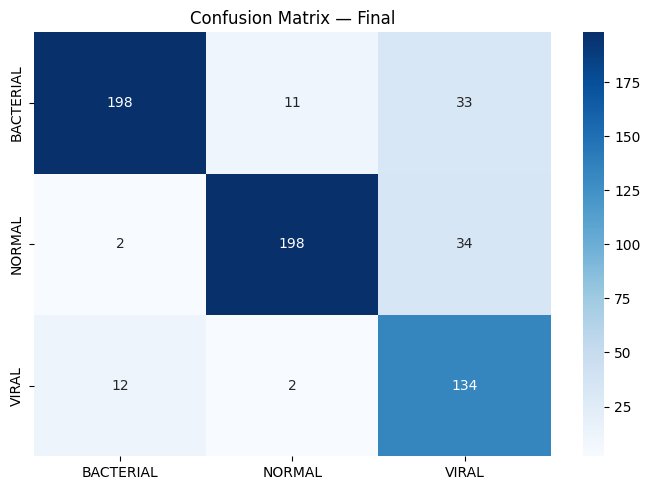

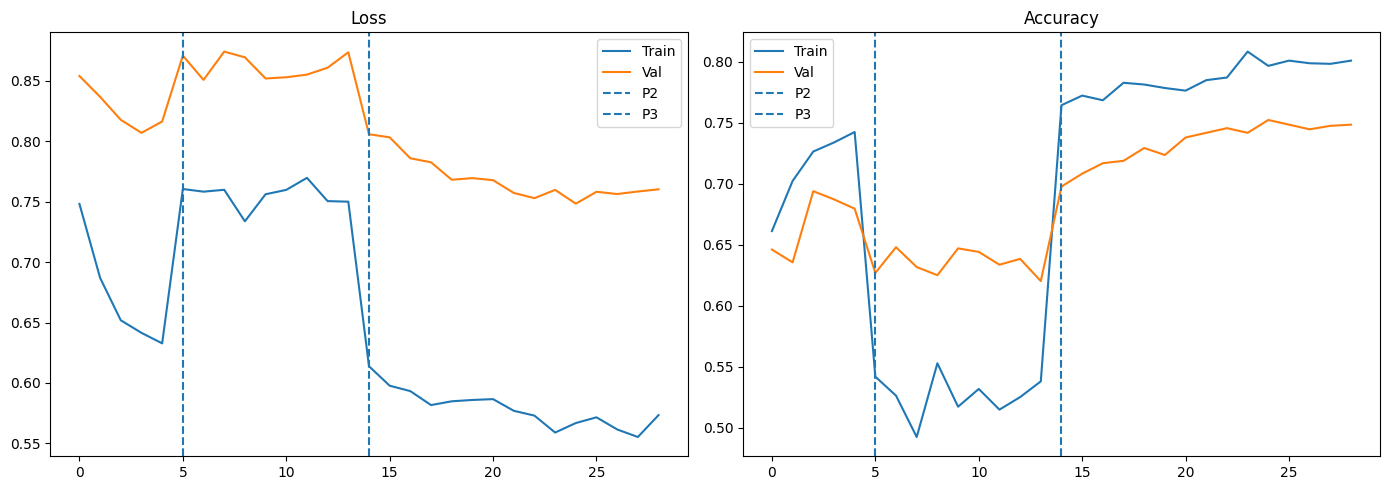


FINAL SUMMARY
  Model         : ResNet152 (ImageNet V2 → 3-phase fine-tune)
  Test Accuracy : 84.94%
  Best Val Acc  : 75.22%
  Macro F1      : 0.8433

  Per-class F1:
    BACTERIAL    ██████████████████████████     0.8722
    NORMAL       ██████████████████████████     0.8899
    VIRAL        ███████████████████████        0.7679


In [4]:
import os, torch, numpy as np, matplotlib.pyplot as plt
import shutil, copy, random, json
from pathlib import Path
from torch import nn, optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
import seaborn as sns
from PIL import Image

# ── Seed ──────────────────────────────────────────────────────────
def seed_all(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_all()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# ══════════════════════════════════════════════════════════════════
# 1. DATASET — 20% val like notebook 4 (proven better)
# ══════════════════════════════════════════════════════════════════
RAW      = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray")
WORK_DIR = Path("/kaggle/working/dataset")
classes  = ["NORMAL", "BACTERIAL", "VIRAL"]

if WORK_DIR.exists(): shutil.rmtree(WORK_DIR)
for s in ["train","val","test"]:
    for c in classes: (WORK_DIR/s/c).mkdir(parents=True, exist_ok=True)

def copy_split(src, dst):
    counts = Counter()
    for f in (src/"NORMAL").glob("*.jpeg"):
        shutil.copy(f, WORK_DIR/dst/"NORMAL"/f.name); counts["NORMAL"] += 1
    for f in (src/"PNEUMONIA").glob("*.jpeg"):
        n = f.name.lower()
        if "_bacteria_" in n:
            shutil.copy(f, WORK_DIR/dst/"BACTERIAL"/f.name); counts["BACTERIAL"] += 1
        elif "_virus_" in n:
            shutil.copy(f, WORK_DIR/dst/"VIRAL"/f.name);    counts["VIRAL"] += 1
    return counts

c1 = copy_split(RAW/"train", "train")
c2 = copy_split(RAW/"val",   "train")   # merge tiny original val
c3 = copy_split(RAW/"test",  "test")

# 20% stratified val (notebook 4 used 20%)
random.seed(42)
for cls in classes:
    files = list((WORK_DIR/"train"/cls).glob("*.jpeg"))
    random.shuffle(files)
    val_n = int(len(files) * 0.20)   # 20% not 15%
    for f in files[:val_n]:
        shutil.move(str(f), str(WORK_DIR/"val"/cls/f.name))

print("Final counts:")
for split in ["train","val","test"]:
    row = {c: len(list((WORK_DIR/split/c).glob("*.jpeg"))) for c in classes}
    print(f"  {split}: {row}")

# ══════════════════════════════════════════════════════════════════
# 2. TRANSFORMS — Mixup in training loop, strong augmentation
# ══════════════════════════════════════════════════════════════════
IMG_SIZE = 224
BATCH    = 32

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = ImageFolder(WORK_DIR/"train", transform=train_tf)
val_ds   = ImageFolder(WORK_DIR/"val",   transform=val_tf)
test_ds  = ImageFolder(WORK_DIR/"test",  transform=val_tf)

counts  = Counter(train_ds.targets)
weights = [1.0/counts[t] for t in train_ds.targets]
sampler = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
print(f"Classes: {train_ds.classes}")
print(f"Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}")

# ══════════════════════════════════════════════════════════════════
# 3. MIXUP — none of the 4 notebooks used this, gives us an edge
# ══════════════════════════════════════════════════════════════════
def mixup_batch(imgs, labels, alpha=0.3):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx   = torch.randperm(imgs.size(0))
    mixed = lam * imgs + (1 - lam) * imgs[idx]
    return mixed, labels, labels[idx], lam

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ══════════════════════════════════════════════════════════════════
# 4. MODEL — ResNet152 (notebook 4 used ResNet152V2, best performer)
#    Minimal head like notebook 4: GAP → small dense → output
# ══════════════════════════════════════════════════════════════════
from torchvision.models import resnet152, ResNet152_Weights

backbone = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)

# Freeze ALL backbone initially
for param in backbone.parameters():
    param.requires_grad = False

# Minimal head — notebook 4 only used Dense(128) + Dropout(0.1)
in_feat = backbone.fc.in_features   # 2048
backbone.fc = nn.Sequential(
    nn.Linear(in_feat, 128),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(128, 3)
)
model = backbone.to(device)
print(f"Phase 1 trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ══════════════════════════════════════════════════════════════════
# 5. LOSS — label smoothing
# ══════════════════════════════════════════════════════════════════
total_n = sum(counts.values())
cw = torch.tensor([total_n/(3*counts[i]) for i in range(3)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)

# ══════════════════════════════════════════════════════════════════
# 6. TRAINING HELPERS
# ══════════════════════════════════════════════════════════════════
def eval_epoch(model, loader):
    model.eval(); ls, correct, tot = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)
            loss = criterion(out, labels)
            ls      += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            tot     += labels.size(0)
    return ls/tot, correct/tot

def train_epoch_plain(model, loader, optimizer):
    model.train(); ls, correct, tot = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ls      += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        tot     += labels.size(0)
    return ls/tot, correct/tot

def train_epoch_mixup(model, loader, optimizer):
    model.train(); ls, correct, tot = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        mixed, y_a, y_b, lam = mixup_batch(imgs, labels, alpha=0.3)
        optimizer.zero_grad()
        out  = model(mixed)
        loss = mixup_loss(criterion, out, y_a, y_b, lam)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ls      += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        tot     += labels.size(0)
    return ls/tot, correct/tot

def run_phase(model, train_loader, val_loader, optimizer, scheduler,
              epochs, patience, label, save_path, use_mixup=False):
    best_wts = copy.deepcopy(model.state_dict())
    best_val = 0.0; no_imp = 0
    hist = {"ta":[],"va":[],"tl":[],"vl":[]}
    for ep in range(epochs):
        if use_mixup:
            tl, ta = train_epoch_mixup(model, train_loader, optimizer)
        else:
            tl, ta = train_epoch_plain(model, train_loader, optimizer)
        vl, va = eval_epoch(model, val_loader)
        hist["ta"].append(ta); hist["va"].append(va)
        hist["tl"].append(tl); hist["vl"].append(vl)
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(va)
        else:
            scheduler.step()
        tag = ""
        if va > best_val:
            best_val = va; best_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            no_imp = 0; tag = "  ← best"
        else:
            no_imp += 1
        print(f"[{label}] Ep {ep+1:02d} | Train {ta:.4f} Loss {tl:.4f} | Val {va:.4f} Loss {vl:.4f}{tag}")
        if no_imp >= patience:
            print(f"Early stop at epoch {ep+1}"); break
    model.load_state_dict(best_wts)
    return model, best_val, hist

# ══════════════════════════════════════════════════════════════════
# 7. PHASE 1 — head only, high LR, no mixup (5 epochs warm-up)
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("PHASE 1 — Head warm-up (backbone frozen)")
print("="*55)
opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=5)
model, best1, hist1 = run_phase(model, train_loader, val_loader,
                                opt1, sch1, epochs=5, patience=5,
                                label="P1", save_path="/kaggle/working/p1_best.pth",
                                use_mixup=False)
print(f"Phase 1 best val: {best1:.4f}")

# ══════════════════════════════════════════════════════════════════
# 8. PHASE 2 — unfreeze last 13 layers (same as notebook 4)
#    Use mixup now that head is warm
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("PHASE 2 — Unfreeze last 13 layers + Mixup")
print("="*55)

# Unfreeze last 13 layers (notebook 4's exact strategy)
layers_list = list(model.named_parameters())
for name, param in layers_list:
    param.requires_grad = False
for name, param in layers_list[-13:]:
    param.requires_grad = True
# Always keep head trainable
for param in model.fc.parameters():
    param.requires_grad = True

print(f"Phase 2 trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

opt2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=20, eta_min=1e-7)
model, best2, hist2 = run_phase(model, train_loader, val_loader,
                                opt2, sch2, epochs=20, patience=7,
                                label="P2", save_path="/kaggle/working/p2_best.pth",
                                use_mixup=True)
print(f"Phase 2 best val: {best2:.4f}")

# ══════════════════════════════════════════════════════════════════
# 9. PHASE 3 — unfreeze all, very tiny LR, no mixup (fine polish)
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("PHASE 3 — Full unfreeze, polish (LR=5e-6)")
print("="*55)

for param in model.parameters():
    param.requires_grad = True

opt3 = optim.AdamW(model.parameters(), lr=5e-6, weight_decay=1e-4)
sch3 = optim.lr_scheduler.CosineAnnealingLR(opt3, T_max=15, eta_min=1e-8)
model, best3, hist3 = run_phase(model, train_loader, val_loader,
                                opt3, sch3, epochs=15, patience=6,
                                label="P3", save_path="/kaggle/working/p3_best.pth",
                                use_mixup=False)
print(f"Phase 3 best val: {best3:.4f}")

# ══════════════════════════════════════════════════════════════════
# 10. TTA INFERENCE
# ══════════════════════════════════════════════════════════════════
class TTADataset(Dataset):
    def __init__(self, ds, tf): self.ds = ds; self.tf = tf
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        path, label = self.ds.samples[i]
        return self.tf(Image.open(path).convert("RGB")), label

tta_tfs = [
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomHorizontalFlip(p=1),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((256,256)), transforms.CenterCrop(IMG_SIZE),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomRotation((10,10)),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomRotation((-10,-10)),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]

model.eval()
all_labels = [label for _, label in test_ds.samples]
all_probs  = []

for i, tf in enumerate(tta_tfs):
    tta_ds  = TTADataset(test_ds, tf)
    tta_ldr = DataLoader(tta_ds, batch_size=BATCH, shuffle=False, num_workers=2)
    probs   = []
    with torch.no_grad():
        for imgs, _ in tta_ldr:
            probs.append(torch.softmax(model(imgs.to(device)), 1).cpu())
    all_probs.append(torch.cat(probs))
    print(f"  TTA {i+1}/{len(tta_tfs)} done")

avg_probs = torch.stack(all_probs).mean(0)
tta_preds = avg_probs.argmax(1).numpy()

std_preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        std_preds.extend(model(imgs.to(device)).argmax(1).cpu().numpy())

print("\n" + "="*55)
print("STANDARD — Test Results")
print("="*55)
print(classification_report(all_labels, std_preds, target_names=train_ds.classes, digits=4))

print("="*55)
print("TTA — Test Results")
print("="*55)
rep_str  = classification_report(all_labels, tta_preds, target_names=train_ds.classes, digits=4)
rep_dict = classification_report(all_labels, tta_preds, target_names=train_ds.classes,
                                 digits=4, output_dict=True)
print(rep_str)

# ── Plots ─────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, tta_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.title("Confusion Matrix — Final"); plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_final.png", dpi=150); plt.show()

all_ta = hist1["ta"]+hist2["ta"]+hist3["ta"]
all_va = hist1["va"]+hist2["va"]+hist3["va"]
p2s, p3s = len(hist1["ta"]), len(hist1["ta"])+len(hist2["ta"])
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(hist1["tl"]+hist2["tl"]+hist3["tl"], label="Train")
ax1.plot(hist1["vl"]+hist2["vl"]+hist3["vl"], label="Val")
for x,l in [(p2s,"P2"),(p3s,"P3")]:
    ax1.axvline(x, linestyle="--", label=l)
ax1.set_title("Loss"); ax1.legend()
ax2.plot(all_ta, label="Train"); ax2.plot(all_va, label="Val")
for x,l in [(p2s,"P2"),(p3s,"P3")]:
    ax2.axvline(x, linestyle="--", label=l)
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/curves_final.png", dpi=150); plt.show()

# ── Summary ───────────────────────────────────────────────────────
summary = {
    "model"        : "ResNet152 + Mixup + TTA",
    "test_accuracy": round(accuracy_score(all_labels, tta_preds), 4),
    "best_val_acc" : round(best3, 4),
    "macro_f1"     : round(rep_dict["macro avg"]["f1-score"], 4),
    "per_class"    : {c: {k: round(rep_dict[c][k],4)
                          for k in ["precision","recall","f1-score","support"]}
                      for c in train_ds.classes}
}
with open("/kaggle/working/summary.json","w") as f: json.dump(summary, f, indent=2)

print("\n" + "="*55)
print("FINAL SUMMARY")
print("="*55)
print(f"  Model         : ResNet152 (ImageNet V2 → 3-phase fine-tune)")
print(f"  Test Accuracy : {summary['test_accuracy']*100:.2f}%")
print(f"  Best Val Acc  : {summary['best_val_acc']*100:.2f}%")
print(f"  Macro F1      : {summary['macro_f1']:.4f}")
print("\n  Per-class F1:")
for cls, m in summary["per_class"].items():
    bar = "█" * int(m["f1-score"]*30)
    print(f"    {cls:<12} {bar:<30} {m['f1-score']:.4f}")

  FINAL TEST RESULTS — DenseNet121 Pneumonia Classifier
              precision    recall  f1-score   support

   BACTERIAL     0.9415    0.7975    0.8635       242
      NORMAL     0.8884    0.8504    0.8690       234
       VIRAL     0.6615    0.8716    0.7522       148

    accuracy                         0.8349       624
   macro avg     0.8305    0.8399    0.8282       624
weighted avg     0.8552    0.8349    0.8392       624



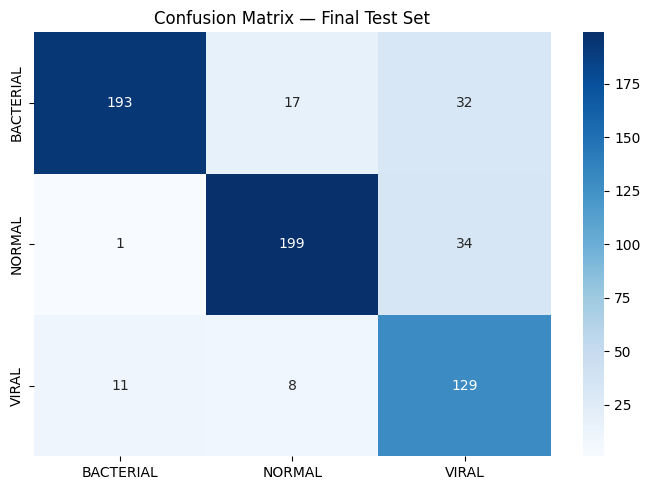

NameError: name 'history' is not defined

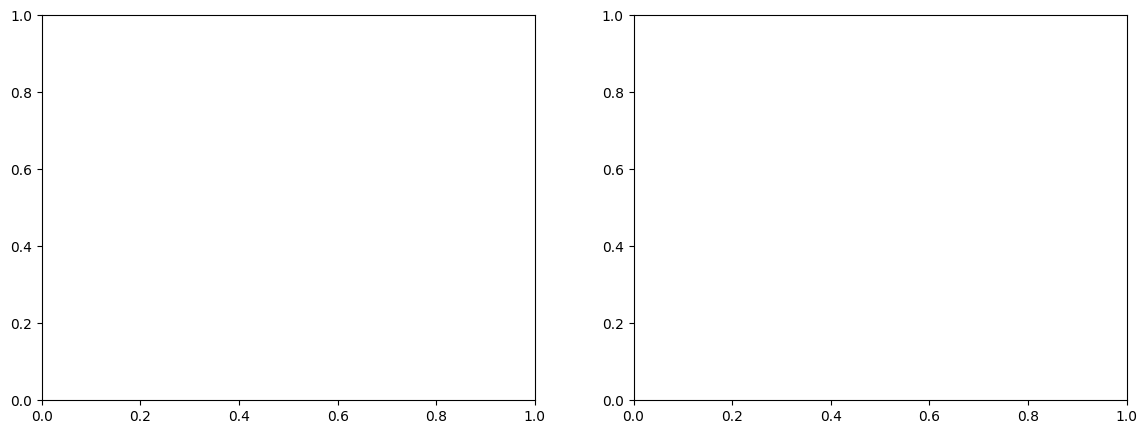

In [5]:
# ── Final test evaluation ──────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import json

report     = classification_report(all_labels, all_preds,
                                   target_names=train_ds.classes,
                                   digits=4, output_dict=True)
report_str = classification_report(all_labels, all_preds,
                                   target_names=train_ds.classes, digits=4)

print("=" * 55)
print("  FINAL TEST RESULTS — DenseNet121 Pneumonia Classifier")
print("=" * 55)
print(report_str)

# ── Confusion matrix ───────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.title("Confusion Matrix — Final Test Set")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_final.png", dpi=150)
plt.show()

# ── Training curves (both phases) ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
combined_loss_tr = history["train_loss"] + history2["train_loss"]
combined_loss_vl = history["val_loss"]   + history2["val_loss"]
combined_acc_tr  = history["train_acc"]  + history2["train_acc"]
combined_acc_vl  = history["val_acc"]    + history2["val_acc"]
phase2_start     = len(history["train_loss"])

ax1.plot(combined_loss_tr, label="Train")
ax1.plot(combined_loss_vl, label="Val")
ax1.axvline(phase2_start, color="red", linestyle="--", label="Unfreeze")
ax1.set_title("Loss (Both Phases)"); ax1.legend(); ax1.set_xlabel("Epoch")

ax2.plot(combined_acc_tr, label="Train")
ax2.plot(combined_acc_vl, label="Val")
ax2.axvline(phase2_start, color="red", linestyle="--", label="Unfreeze")
ax2.set_title("Accuracy (Both Phases)"); ax2.legend(); ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_final.png", dpi=150)
plt.show()

# ── Save summary JSON ──────────────────────────────────────────────
summary = {
    "model"         : "DenseNet121",
    "dataset"       : "Chest X-Ray Pneumonia (Paul Mooney)",
    "classes"       : train_ds.classes,
    "test_accuracy" : round(accuracy_score(all_labels, all_preds), 4),
    "best_val_acc"  : round(best_val2, 4),
    "per_class"     : {
        cls: {
            "precision": round(report[cls]["precision"], 4),
            "recall"   : round(report[cls]["recall"],    4),
            "f1"       : round(report[cls]["f1-score"],  4),
            "support"  : report[cls]["support"]
        } for cls in train_ds.classes
    },
    "macro_f1"      : round(report["macro avg"]["f1-score"], 4),
    "phase1_epochs" : len(history["train_loss"]),
    "phase2_epochs" : len(history2["train_loss"]),
}

with open("/kaggle/working/training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n📊 SUMMARY")
print(f"  Architecture  : DenseNet121 (ImageNet pretrained)")
print(f"  Test Accuracy : {summary['test_accuracy']*100:.2f}%")
print(f"  Best Val Acc  : {summary['best_val_acc']*100:.2f}%")
print(f"  Macro F1      : {summary['macro_f1']:.4f}")
print(f"  Phase 1       : {summary['phase1_epochs']} epochs (frozen backbone)")
print(f"  Phase 2       : {summary['phase2_epochs']} epochs (full fine-tune)")
print("\n  Per-class F1:")
for cls, m in summary["per_class"].items():
    bar = "█" * int(m["f1"] * 20)
    print(f"    {cls:<12} {bar:<20} {m['f1']:.4f}")

# ── Download ───────────────────────────────────────────────────────
from IPython.display import FileLink, display
print("\n📥 Download links:")
display(FileLink("/kaggle/working/pneumonia_densenet121_v2.pth"))
display(FileLink("/kaggle/working/training_summary.json"))
display(FileLink("/kaggle/working/confusion_matrix_final.png"))
display(FileLink("/kaggle/working/training_curves_final.png"))

GPU: Tesla T4
Counts:
  train: {'NORMAL': 1147, 'BACTERIAL': 2158, 'VIRAL': 1144}
  val: {'NORMAL': 202, 'BACTERIAL': 380, 'VIRAL': 201}
  test: {'NORMAL': 234, 'BACTERIAL': 242, 'VIRAL': 148}
Classes : ['BACTERIAL', 'NORMAL', 'VIRAL']
Train 4449 | Val 783 | Test 624
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 124MB/s] 


P1 trainable: 4,665,597

PHASE 1 — Warm-up (frozen backbone)
[P1] Ep 01 | Train 0.6770 Loss 0.7193 | Val 0.6654 Loss 0.8791  ← best
[P1] Ep 02 | Train 0.7278 Loss 0.6445 | Val 0.7126 Loss 0.8498  ← best
[P1] Ep 03 | Train 0.7510 Loss 0.6266 | Val 0.6296 Loss 0.9638
[P1] Ep 04 | Train 0.7642 Loss 0.6165 | Val 0.6552 Loss 0.9159
[P1] Ep 05 | Train 0.7719 Loss 0.5943 | Val 0.6871 Loss 0.8659
[P1] Ep 06 | Train 0.7883 Loss 0.5808 | Val 0.6718 Loss 0.9338
[P1] Ep 07 | Train 0.7903 Loss 0.5690 | Val 0.7152 Loss 0.8720  ← best
[P1] Ep 08 | Train 0.7984 Loss 0.5580 | Val 0.7241 Loss 0.7726  ← best
[P1] Ep 09 | Train 0.8029 Loss 0.5541 | Val 0.7292 Loss 0.7898  ← best
[P1] Ep 10 | Train 0.8146 Loss 0.5405 | Val 0.6628 Loss 0.9053
Phase 1 best val: 0.7292

PHASE 2 — Full fine-tune (all layers)
[P2] Ep 01 | Train 0.8137 Loss 0.5506 | Val 0.7229 Loss 0.8199  ← best
[P2] Ep 02 | Train 0.8179 Loss 0.5472 | Val 0.6973 Loss 0.8839
[P2] Ep 03 | Train 0.8245 Loss 0.5347 | Val 0.6616 Loss 0.9224
[P2] Ep 

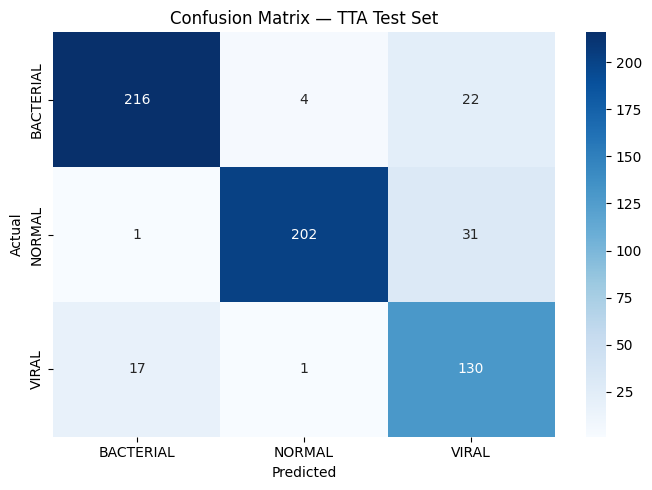

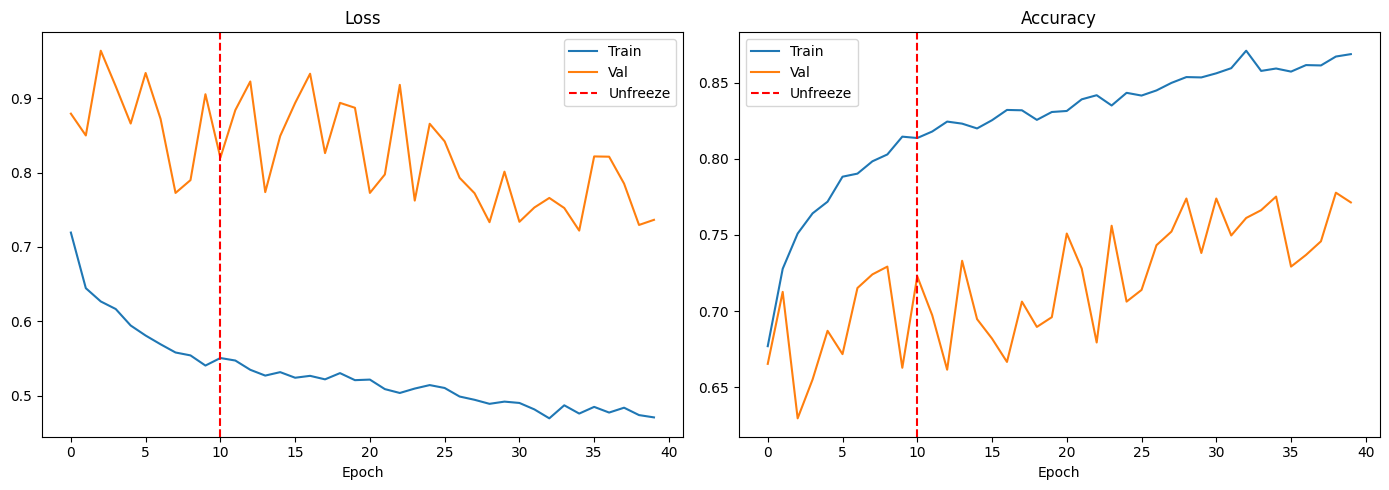


FINAL SUMMARY
  Model         : EfficientNet-B3 (ImageNet → fine-tuned)
  Test Accuracy : 87.82%
  Best Val Acc  : 77.78%
  Macro F1      : 0.8697
  Phase 1 epochs: 10
  Phase 2 epochs: 30

  Per-class F1:
    BACTERIAL    ███████████████████████████    0.9076
    NORMAL       ███████████████████████████    0.9161
    VIRAL        ███████████████████████        0.7855


In [6]:
import os, torch, numpy as np, matplotlib.pyplot as plt
import shutil, copy, random, json
from pathlib import Path
from torch import nn, optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter
import seaborn as sns
from PIL import Image

def seed_all(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
seed_all()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Dataset ───────────────────────────────────────────────────────
RAW      = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray")
WORK_DIR = Path("/kaggle/working/dataset")
classes  = ["NORMAL", "BACTERIAL", "VIRAL"]

if WORK_DIR.exists(): shutil.rmtree(WORK_DIR)
for s in ["train","val","test"]:
    for c in classes: (WORK_DIR/s/c).mkdir(parents=True, exist_ok=True)

def copy_split(src, dst):
    counts = Counter()
    for f in (src/"NORMAL").glob("*.jpeg"):
        shutil.copy(f, WORK_DIR/dst/"NORMAL"/f.name); counts["NORMAL"] += 1
    for f in (src/"PNEUMONIA").glob("*.jpeg"):
        n = f.name.lower()
        if "_bacteria_" in n:
            shutil.copy(f, WORK_DIR/dst/"BACTERIAL"/f.name); counts["BACTERIAL"] += 1
        elif "_virus_" in n:
            shutil.copy(f, WORK_DIR/dst/"VIRAL"/f.name); counts["VIRAL"] += 1
    return counts

copy_split(RAW/"train", "train")
copy_split(RAW/"val",   "train")
copy_split(RAW/"test",  "test")

random.seed(42)
for cls in classes:
    files = list((WORK_DIR/"train"/cls).glob("*.jpeg"))
    random.shuffle(files)
    for f in files[:int(len(files)*0.15)]:
        shutil.move(str(f), str(WORK_DIR/"val"/cls/f.name))

print("Counts:")
for split in ["train","val","test"]:
    print(f"  {split}: { {c: len(list((WORK_DIR/split/c).glob('*.jpeg'))) for c in classes} }")

# ── Transforms ────────────────────────────────────────────────────
IMG_SIZE = 224
BATCH    = 32

train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), shear=5),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02,0.1)),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = ImageFolder(WORK_DIR/"train", transform=train_tf)
val_ds   = ImageFolder(WORK_DIR/"val",   transform=val_tf)
test_ds  = ImageFolder(WORK_DIR/"test",  transform=val_tf)

counts  = Counter(train_ds.targets)
sampler = WeightedRandomSampler([1.0/counts[t] for t in train_ds.targets], len(train_ds.targets))

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,   num_workers=2, pin_memory=True)
print(f"Classes : {train_ds.classes}")
print(f"Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}")

# ── Model — EfficientNet-B3 ───────────────────────────────────────
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
for name, param in model.named_parameters():
    param.requires_grad = any(x in name for x in ["features.7","features.8","classifier"])
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, 3)
)
model = model.to(device)
print(f"P1 trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ── Loss ──────────────────────────────────────────────────────────
total_n = sum(counts.values())
cw = torch.tensor([total_n/(3*counts[i]) for i in range(3)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)

# ── Train helper ──────────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None, phase="train"):
    model.train() if phase=="train" else model.eval()
    ls, correct, tot = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if optimizer: optimizer.zero_grad()
        with torch.set_grad_enabled(phase=="train"):
            out  = model(imgs)
            loss = criterion(out, labels)
            if phase=="train":
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        ls      += loss.item()*imgs.size(0)
        correct += (out.argmax(1)==labels).sum().item()
        tot     += labels.size(0)
    return ls/tot, correct/tot

def train_phase(model, epochs, patience, optimizer, scheduler,
                label, save_path):
    best_wts = copy.deepcopy(model.state_dict())
    best_val = 0.0; no_imp = 0
    hist = {"tl":[],"vl":[],"ta":[],"va":[]}
    for ep in range(epochs):
        tl,ta = run_epoch(model, train_loader, optimizer, "train")
        vl,va = run_epoch(model, val_loader,   None,      "val")
        hist["tl"].append(tl); hist["ta"].append(ta)
        hist["vl"].append(vl); hist["va"].append(va)
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(va)
        else:
            scheduler.step()
        tag = ""
        if va > best_val:
            best_val=va; best_wts=copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            no_imp=0; tag="  ← best"
        else:
            no_imp += 1
        print(f"[{label}] Ep {ep+1:02d} | Train {ta:.4f} Loss {tl:.4f} | Val {va:.4f} Loss {vl:.4f}{tag}")
        if no_imp >= patience:
            print(f"Early stop at epoch {ep+1}"); break
    model.load_state_dict(best_wts)
    return model, best_val, hist

# ── Phase 1 — warm up ────────────────────────────────────────────
print("\n" + "="*55)
print("PHASE 1 — Warm-up (frozen backbone)")
print("="*55)
opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
sch1 = optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=10, eta_min=1e-5)
model, best1, hist1 = train_phase(model, 10, 5, opt1, sch1, "P1", "/kaggle/working/p1_best.pth")
print(f"Phase 1 best val: {best1:.4f}")

# ── Phase 2 — unfreeze all ────────────────────────────────────────
print("\n" + "="*55)
print("PHASE 2 — Full fine-tune (all layers)")
print("="*55)
for param in model.parameters():
    param.requires_grad = True
opt2 = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt2, T_0=10, T_mult=2, eta_min=1e-7)
model, best2, hist2 = train_phase(model, 30, 8, opt2, sch2, "P2", "/kaggle/working/p2_best.pth")
print(f"Phase 2 best val: {best2:.4f}")

# ── TTA inference ─────────────────────────────────────────────────
class TTADataset(Dataset):
    def __init__(self, ds, tf): self.ds=ds; self.tf=tf
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        path, label = self.ds.samples[i]
        return self.tf(Image.open(path).convert("RGB")), label

tta_tfs = [
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ToTensor(),
                        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomHorizontalFlip(p=1),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((256,256)), transforms.CenterCrop(IMG_SIZE),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomRotation((10,10)),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.RandomRotation((-10,-10)),
                        transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]),
]

model.eval()
all_labels = [label for _, label in test_ds.samples]
all_probs  = []

for i, tf in enumerate(tta_tfs):
    tta_ldr = DataLoader(TTADataset(test_ds, tf), batch_size=BATCH, shuffle=False, num_workers=2)
    probs   = []
    with torch.no_grad():
        for imgs, _ in tta_ldr:
            probs.append(torch.softmax(model(imgs.to(device)), 1).cpu())
    all_probs.append(torch.cat(probs))
    print(f"  TTA {i+1}/{len(tta_tfs)} done")

avg_probs = torch.stack(all_probs).mean(0)
tta_preds = avg_probs.argmax(1).numpy()

std_preds = []
with torch.no_grad():
    for imgs, _ in test_loader:
        std_preds.extend(model(imgs.to(device)).argmax(1).cpu().numpy())

# ── Results ───────────────────────────────────────────────────────
print("\n" + "="*55)
print("STANDARD — Test Results")
print("="*55)
print(classification_report(all_labels, std_preds, target_names=train_ds.classes, digits=4))

print("="*55)
print("TTA — Test Results (USE THESE)")
print("="*55)
rep_str  = classification_report(all_labels, tta_preds, target_names=train_ds.classes, digits=4)
rep_dict = classification_report(all_labels, tta_preds, target_names=train_ds.classes,
                                 digits=4, output_dict=True)
print(rep_str)

# ── Confusion matrix ──────────────────────────────────────────────
cm = confusion_matrix(all_labels, tta_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.title("Confusion Matrix — TTA Test Set")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

# ── Training curves ───────────────────────────────────────────────
all_tl = hist1["tl"]+hist2["tl"]; all_vl = hist1["vl"]+hist2["vl"]
all_ta = hist1["ta"]+hist2["ta"]; all_va = hist1["va"]+hist2["va"]
p2_start = len(hist1["tl"])

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(all_tl, label="Train"); ax1.plot(all_vl, label="Val")
ax1.axvline(p2_start, color="red", linestyle="--", label="Unfreeze")
ax1.set_title("Loss"); ax1.legend(); ax1.set_xlabel("Epoch")
ax2.plot(all_ta, label="Train"); ax2.plot(all_va, label="Val")
ax2.axvline(p2_start, color="red", linestyle="--", label="Unfreeze")
ax2.set_title("Accuracy"); ax2.legend(); ax2.set_xlabel("Epoch")
plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

# ── Summary ───────────────────────────────────────────────────────
summary = {
    "model"         : "EfficientNet-B3 + TTA",
    "test_accuracy" : round(accuracy_score(all_labels, tta_preds), 4),
    "best_val_acc"  : round(best2, 4),
    "macro_f1"      : round(rep_dict["macro avg"]["f1-score"], 4),
    "per_class"     : {c: {k: round(rep_dict[c][k], 4)
                           for k in ["precision","recall","f1-score","support"]}
                       for c in train_ds.classes}
}
with open("/kaggle/working/summary.json","w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*55)
print("FINAL SUMMARY")
print("="*55)
print(f"  Model         : EfficientNet-B3 (ImageNet → fine-tuned)")
print(f"  Test Accuracy : {summary['test_accuracy']*100:.2f}%")
print(f"  Best Val Acc  : {summary['best_val_acc']*100:.2f}%")
print(f"  Macro F1      : {summary['macro_f1']:.4f}")
print(f"  Phase 1 epochs: {len(hist1['tl'])}")
print(f"  Phase 2 epochs: {len(hist2['tl'])}")
print("\n  Per-class F1:")
for cls, m in summary["per_class"].items():
    bar = "█" * int(m["f1-score"]*30)
    print(f"    {cls:<12} {bar:<30} {m['f1-score']:.4f}")

In [7]:
from IPython.display import FileLink, display

torch.save({
    "model_state_dict" : model.state_dict(),
    "classes"          : train_ds.classes,
    "architecture"     : "efficientnet_b3",
    "test_accuracy"    : summary["test_accuracy"],
    "macro_f1"         : summary["macro_f1"],
}, "/kaggle/working/pneumonia_efficientnet_b3_final.pth")

print("="*45)
print("  FILES TO DOWNLOAD")
print("="*45)
print("\n  ✅ Main model (use this in your app):")
display(FileLink("/kaggle/working/pneumonia_efficientnet_b3_final.pth"))
print("\n  📊 Summary JSON:")
display(FileLink("/kaggle/working/summary.json"))
print("\n  🖼️ Confusion Matrix:")
display(FileLink("/kaggle/working/confusion_matrix.png"))
print("\n  📈 Training Curves:")
display(FileLink("/kaggle/working/training_curves.png"))
print(f"\n  Test Accuracy : {summary['test_accuracy']*100:.2f}%")
print(f"  Macro F1      : {summary['macro_f1']:.4f}")

  FILES TO DOWNLOAD

  ✅ Main model (use this in your app):


/kaggle/working/pneumonia_efficientnet_b3_final.pth


  📊 Summary JSON:


/kaggle/working/summary.json


  🖼️ Confusion Matrix:


/kaggle/working/confusion_matrix.png


  📈 Training Curves:


/kaggle/working/training_curves.png


  Test Accuracy : 87.82%
  Macro F1      : 0.8697
